# 02_ner_training.ipynb

## Setup

In [1]:
import os
import sys
from pathlib import Path

# Mount colab
if True:
    if not os.path.exists('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')

PROJECT_ROOT: Path = Path("/content/drive/MyDrive/python/projects/nlp_projects/med/biomedical-extraction-pipeline")
os.chdir(PROJECT_ROOT)

# Add the PROJECT_ROOT directory to the Python path to import modules
if str(PROJECT_ROOT) in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"ℹ️ Current Python version: {sys.version}")

ℹ️ Current Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# Install reqs (NOTE: restart after this)
if False:
    %pip install -r {"requirements/02_ner_training.txt"}

In [ ]:
# --- src ---
from src.config import load_configs
from src.utils import (
    dynamic_module_reloader, 
    seed_everything, 
    plot_length_distribution_with_percentiles,
    estimate_optimization_steps
    )
from src.model_utils.ner_utils import tokenize_and_align_labels, compute_metrics_ner

# --- other ---
import time
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import torch
import trackio
from functools import partial
from dotenv import load_dotenv
from pprint import pprint
from datasets import DatasetDict
from transformers import (
    AutoConfig, 
    AutoTokenizer,
    AutoModelForTokenClassification, 
    DataCollatorForTokenClassification, 
    EarlyStoppingCallback,
    TrainingArguments, 
    Trainer
    )
from peft import get_peft_model, LoraConfig, TaskType

MODULES_TO_RELOAD = [
    "src",
    "src.config",
    "src.utils",
    "src.model_utils",
    "src.model_utils.ner_utils",
]

dynamic_module_reloader(modules=MODULES_TO_RELOAD, verbose=1)
config = load_configs()
load_dotenv()
seed_everything(config.env.seed)
pprint(config.to_dict())

# Constants
DEVICE: str = 'cuda' if torch.cuda.is_available() else 'cpu'
SMOKE_TEST: bool = False
SAVE_LOCAL: bool = True
PUSH_TO_HUB: bool = True

if SMOKE_TEST:
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    config.model.ner_model_name += f"-smoke-test-{current_time}"
    config.tracking.project = "smoke-tests"

# Assertions to prevent incompatible settings
assert not (SMOKE_TEST and PUSH_TO_HUB), "Cannot run in SMOKE_TEST mode and PUSH_TO_HUB at the same time."
assert not (SMOKE_TEST and SAVE_LOCAL), "Cannot run in SMOKE_TEST mode and SAVE_LOCAL at the same time."
assert not (DEVICE=='cpu' and not SMOKE_TEST), "Running on CPU without SMOKE_TEST mode can be very slow. Please set SMOKE_TEST to True or use a GPU."

print("\n\t--- Notebook settings ---")
print(f"Using device: {DEVICE}")
print(f"SMOKE_TEST mode: {SMOKE_TEST}")

Reloaded: src
Reloaded: src.config
Reloaded: src.utils
Reloaded: src.model_utils
Reloaded: src.model_utils.ner_utils
✅ Seed set to 42
{'data': {'data_folder': PosixPath('data/documents'),
          'dataset_name': 'bigbio/bc5cdr'},
 'env': {'seed': 42},
 'model': {'ner_label_names': ['O',
                               'B-Chemical',
                               'I-Chemical',
                               'B-Disease',
                               'I-Disease'],
           'ner_model_checkpoint': 'microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract',
           'ner_model_name': 'BiomedNLP-PubMedBERT-base-uncased-ner-abstract-bc5cdr-v1.1'},
 'tracking': {'project': 'Biomed-IE',
              'tracker': 'trackio',
              'trackio_space_id': 'Francesco-A/nlp-tracking'}}

	--- Notebook settings ---
Using device: cuda
SMOKE_TEST mode: False


In [3]:
!nvidia-smi

Sat Jun  6 10:09:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             30W /   70W |     695MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data

In [4]:
# Load the processed dataset (bigbio/BC5CDR)
flattened_dataset = DatasetDict.load_from_disk("data/processed/bc5cdr_flattened_hf")
flattened_dataset

DatasetDict({
    train: Dataset({
        features: ['document_id', 'text', 'entities', 'relations'],
        num_rows: 500
    })
    test: Dataset({
        features: ['document_id', 'text', 'entities', 'relations'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['document_id', 'text', 'entities', 'relations'],
        num_rows: 500
    })
})

In [5]:
# id2label & label2id
id2label = {i: label for i, label in enumerate(config.model.ner_label_names)}
label2id = {label: i for i, label in enumerate(config.model.ner_label_names)}

print(f"id2label: {id2label}")
print(f"label2id: {label2id}")

id2label: {0: 'O', 1: 'B-Chemical', 2: 'I-Chemical', 3: 'B-Disease', 4: 'I-Disease'}
label2id: {'O': 0, 'B-Chemical': 1, 'I-Chemical': 2, 'B-Disease': 3, 'I-Disease': 4}


In [6]:
# Instantiate the tokenizer and data_collator [OPTIONAL]
model_checkpoint = config.model.ner_model_checkpoint
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
data_collator = DataCollatorForTokenClassification(tokenizer)

# Tokenize (+ offsets and BIO tagging)
tokenize_fn = partial(
    tokenize_and_align_labels, 
    tokenizer=tokenizer,
    padding=data_collator is None,
    truncate=True
    )

tokenized_dataset = flattened_dataset.map(tokenize_fn, batched=True)

# Add ner-tags (str) [OPTIONAL]
if True:
    def int_to_string(example):
        example["ner-tags"] = [
            "IGNORE" if label == -100 else id2label[label] 
            for label in example["labels"]
        ]
        return example
    tokenized_dataset = tokenized_dataset.map(int_to_string)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['document_id', 'text', 'entities', 'relations', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels', 'ner-tags'],
        num_rows: 500
    })
    test: Dataset({
        features: ['document_id', 'text', 'entities', 'relations', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels', 'ner-tags'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['document_id', 'text', 'entities', 'relations', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels', 'ner-tags'],
        num_rows: 500
    })
})

With `lambda` it would be like:

```python
tokenized_dataset = flattened_dataset['train'].map(
    lambda examples: tokenize_and_align_labels(examples, tokenizer=tokenizer),
    batched=True
)
```

Either [`partial`](https://stackoverflow.com/questions/15331726/how-does-functools-partial-do-what-it-does) or `lambda` work here. `partial`, however, is generally faster and more memory-efficient than a `lambda` for batched operations because it avoids the overhead of creating a new function frame every time it is called.

In [7]:
# Sanity check of offsets and BIO tags in tokenized dataset (horizontal)
if True:
    sample = tokenized_dataset["train"][0]
    tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])
    print("Original text:", sample["text"])
    print("Tokens:", tokens)
    print("Offsets:", sample["offset_mapping"])
    print("BIO tags:", sample["labels"])
    print("BIO tags (str):", sample["ner-tags"])

    print("\nToken-BIO Tag pairs:")
    display(
        pd.DataFrame(
            zip(tokens, sample["labels"], sample["ner-tags"]),
            columns=["Token", "BIO Tag", "BIO Tag (str)"]
        ))

Original text: Naloxone reverses the antihypertensive effect of clonidine. In unanesthetized, spontaneously hypertensive rats the decrease in blood pressure and heart rate produced by intravenous clonidine, 5 to 20 micrograms/kg, was inhibited or reversed by nalozone, 0.2 to 2 mg/kg. The hypotensive effect of 100 mg/kg alpha-methyldopa was also partially reversed by naloxone. Naloxone alone did not affect either blood pressure or heart rate. In brain membranes from spontaneously hypertensive rats clonidine, 10(-8) to 10(-5) M, did not influence stereoselective binding of [3H]-naloxone (8 nM), and naloxone, 10(-8) to 10(-4) M, did not influence clonidine-suppressible binding of [3H]-dihydroergocryptine (1 nM). These findings indicate that in spontaneously hypertensive rats the effects of central alpha-adrenoceptor stimulation involve activation of opiate receptors. As naloxone and clonidine do not appear to interact with the same receptor site, the observed functional antagonism suggest

,Token,BIO Tag,BIO Tag (str)
0,[CLS],-100,IGNORE
1,naloxone,1,B-Chemical
2,reverse,0,O
3,##s,0,O
4,the,0,O
...,...,...,...
234,of,0,O
235,sympathetic,0,O
236,tone,0,O
237,.,0,O


Checking token length distribution and model max length (with truncation=True)


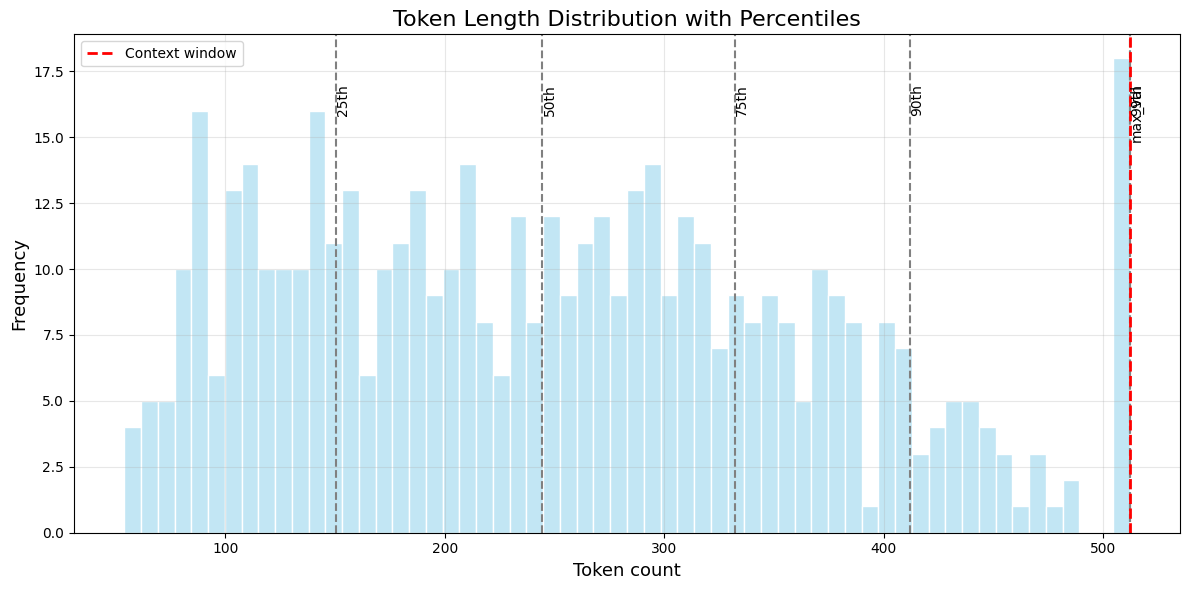

____________________________________________________________________________________________________
There's 0 sample(s) exceeding model_max_length


In [8]:
# Check token length distribution and model max length
if True:
    print("Checking token length distribution and model max length (with truncation=True)")
    token_lengths = [len(sample["input_ids"]) for sample in tokenized_dataset["train"]]
    model_max_length = AutoConfig.from_pretrained(model_checkpoint).max_position_embeddings
    plot_length_distribution_with_percentiles(token_lengths, model_max_length=model_max_length)

In [9]:
if SMOKE_TEST:
    n_samples = 25
    print(f"ℹ️Dataset downsampled for smoke-test ({n_samples} samples per split)")
    tokenized_dataset = DatasetDict({
        split: tokenized_dataset[split].select(range(n_samples)) for split in tokenized_dataset.keys()
    })

## Training

### LoRA configs

In [ ]:
model_config = AutoConfig.from_pretrained(
    model_checkpoint,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
)

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint, 
    config=model_config,
    device_map="auto",
) #.to(DEVICE)

peft_config = LoraConfig(
    task_type=TaskType.TOKEN_CLS, 
    r=16, 
    lora_alpha=32, 
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
# Note: You should see that only ~1-2% of total parameters are trainable!

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

N

trainable params: 593,669 || all params: 109,489,162 || trainable%: 0.5422


### Training configs

In [17]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001
)

compute_metrics_fn = partial(compute_metrics_ner, label_list=list(id2label.values()))

training_args = TrainingArguments(
    output_dir=f"results/{config.model.ner_model_name}",
    # log_level="info",
    
    num_train_epochs=20 if not SMOKE_TEST else 3,
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    eval_accumulation_steps=4,
    weight_decay=0.01,
    warmup_steps=20,
    lr_scheduler_type='linear',
    seed=config.env.seed,
    learning_rate = 2e-4, # LoRA typically prefers slightly higher learning rates,

    # eval_steps = 10,
    eval_strategy ="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,

    report_to = config.tracking.tracker,
    run_name = f"{config.tracking.project}/{config.model.ner_model_name}",
    project = config.tracking.project,
    trackio_space_id  = config.tracking.trackio_space_id,
    push_to_hub = False, # False: push only the best model (after training completion)
    hub_private_repo = False,
    hub_model_id = config.model.ner_model_name,
)

In [19]:
estimate_optimization_steps(
    tokenized_dataset["train"], 
    batch_size=training_args.per_device_train_batch_size,
    gradient_accumulation_steps=training_args.gradient_accumulation_steps
)

Per-step batch size is: 4
Gradient accumulation steps: 4
Effective batch size is: 16
The dataset has 500 examples
One full pass (epoch) through the dataset corresponds to roughly
500/16 ≈ 31 optimization steps.


In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics_fn,
    data_collator=data_collator,
    callbacks=[early_stopping]
)

if True:
    start = time.time()
    trainer.train(resume_from_checkpoint=False)
    end = time.time()
    print("Training finished. Checkpoint saved to:", trainer.state.best_model_checkpoint if trainer.state else "N/A")
    print(f"Training time: {(end - start)/60:.2f} min")

    if PUSH_TO_HUB:
        trainer.push_to_hub(commit_message="Upload adapter weights and tokenizer")
        trainer.model.config.push_to_hub(
            commit_message="Pushing configs (with label mappings)",
            repo_id=trainer.args.hub_model_id
        )

* Trackio project initialized: Biomed-IE
* Trackio metrics will be synced to Hugging Face Bucket: https://huggingface.co/buckets/Francesco-A/nlp-tracking-bucket
* Found existing space: https://huggingface.co/spaces/Francesco-A/nlp-tracking


* NVIDIA GPU detected, enabling automatic GPU metrics logging
* Created new run: Biomed-IE/BiomedNLP-PubMedBERT-base-uncased-ner-abstract-bc5cdr-v1.1


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,4.822943,0.581317,0.000000,0.000000,0.000000,0.851171
2,1.649036,0.225588,0.647335,0.703557,0.674276,0.941202
3,0.715858,0.124927,0.772228,0.832952,0.801441,0.962307
4,0.487537,0.102275,0.829959,0.814333,0.822072,0.966185
5,0.427731,0.106020,0.773413,0.880487,0.823484,0.964088
6,0.381472,0.093751,0.827211,0.845538,0.836274,0.967723
7,0.350259,0.088379,0.819635,0.874454,0.846158,0.969714
8,0.327235,0.089624,0.820528,0.876430,0.847558,0.969625
9,0.305709,0.094326,0.793801,0.889744,0.839039,0.967431
10,0.287684,0.088172,0.821411,0.880279,0.849827,0.969682


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 2.38MB / 2.38MB            

  ...dr-v1.1/training_args.bin: 100%|##########| 5.46kB / 5.46kB            

README.md:   0%|          | 0.00/3.00k [00:00<?, ?B/s]

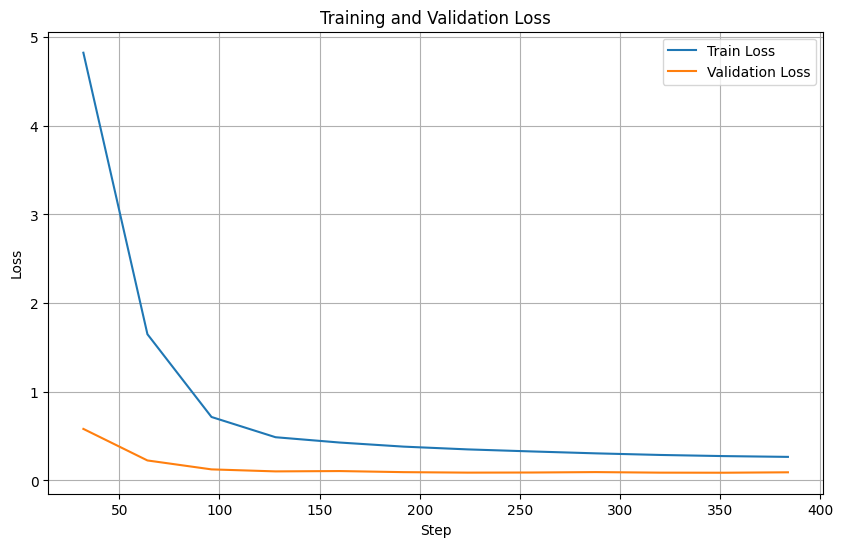

In [ ]:
# Convert the history list to a DataFrame
history_df = pd.DataFrame(trainer.state.log_history)
grouped_history = history_df.groupby("epoch").first().reset_index()

# Plot train history and save in evals/images with name config.model.ner_model_name+"_"+"training_history.png" in 300 dpi
plt.figure(figsize=(10, 6))
plt.plot(grouped_history["step"], grouped_history["loss"], label="Train Loss")
plt.plot(grouped_history["step"], grouped_history["eval_loss"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

if True:
    plt.savefig(f"evals/images/{config.model.ner_model_name}_train_history.png", dpi=300, bbox_inches='tight')

plt.show()

## Requirements (full snapshot)

In [17]:
if True:
    !pip freeze > snapshots/02_ner_training.txt